# Explore Customer Distribution based on Custom Segmentation
**This notebook explores how the customer segments are distributed and spread. It also checks the individual affects Recency, Frequency and Monetary along with their paired affects on each segments**

### Import required libraries along with config to import and work with data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))

from config import RFM_DATA_PATH

%matplotlib inline

In [3]:
df = pd.read_csv(RFM_DATA_PATH)
df.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation
0,12346,326,1,77183.60,1,1,5,115,Standard Customer
1,12347,2,7,4310.00,5,5,5,555,VIP
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Standard Customer
4,12350,310,1,334.40,1,1,2,112,Hibernating


In [123]:
df.describe().round(2)

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,log_recency,log_frequency,log_monetary
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27,3.02,3.00,3.00,334.54,3.83,1.35,6.59
std,1721.81,100.01,7.70,8989.23,1.41,1.41,1.41,150.07,1.34,0.68,1.26
min,12346.00,1.00,1.00,3.75,1.00,1.00,1.00,111.00,0.69,0.69,1.56
25%,13813.25,18.00,1.00,307.41,2.00,2.00,2.00,221.00,2.94,0.69,5.73
50%,15299.50,51.00,2.00,674.48,3.00,3.00,3.00,333.00,3.95,1.10,6.52
75%,16778.75,142.00,5.00,1661.74,4.00,4.00,4.00,454.00,4.96,1.79,7.42
max,18287.00,374.00,209.00,280206.02,5.00,5.00,5.00,555.00,5.93,5.35,12.54


### Log Transformed to reduce skewness

In [40]:
df["log_recency"] = np.log1p(df["Recency"])
df["log_frequency"] = np.log1p(df["Frequency"])
df["log_monetary"] = np.log1p(df["Monetary"])

### Plot Kernel Density Estimate for better visualization of data distribution

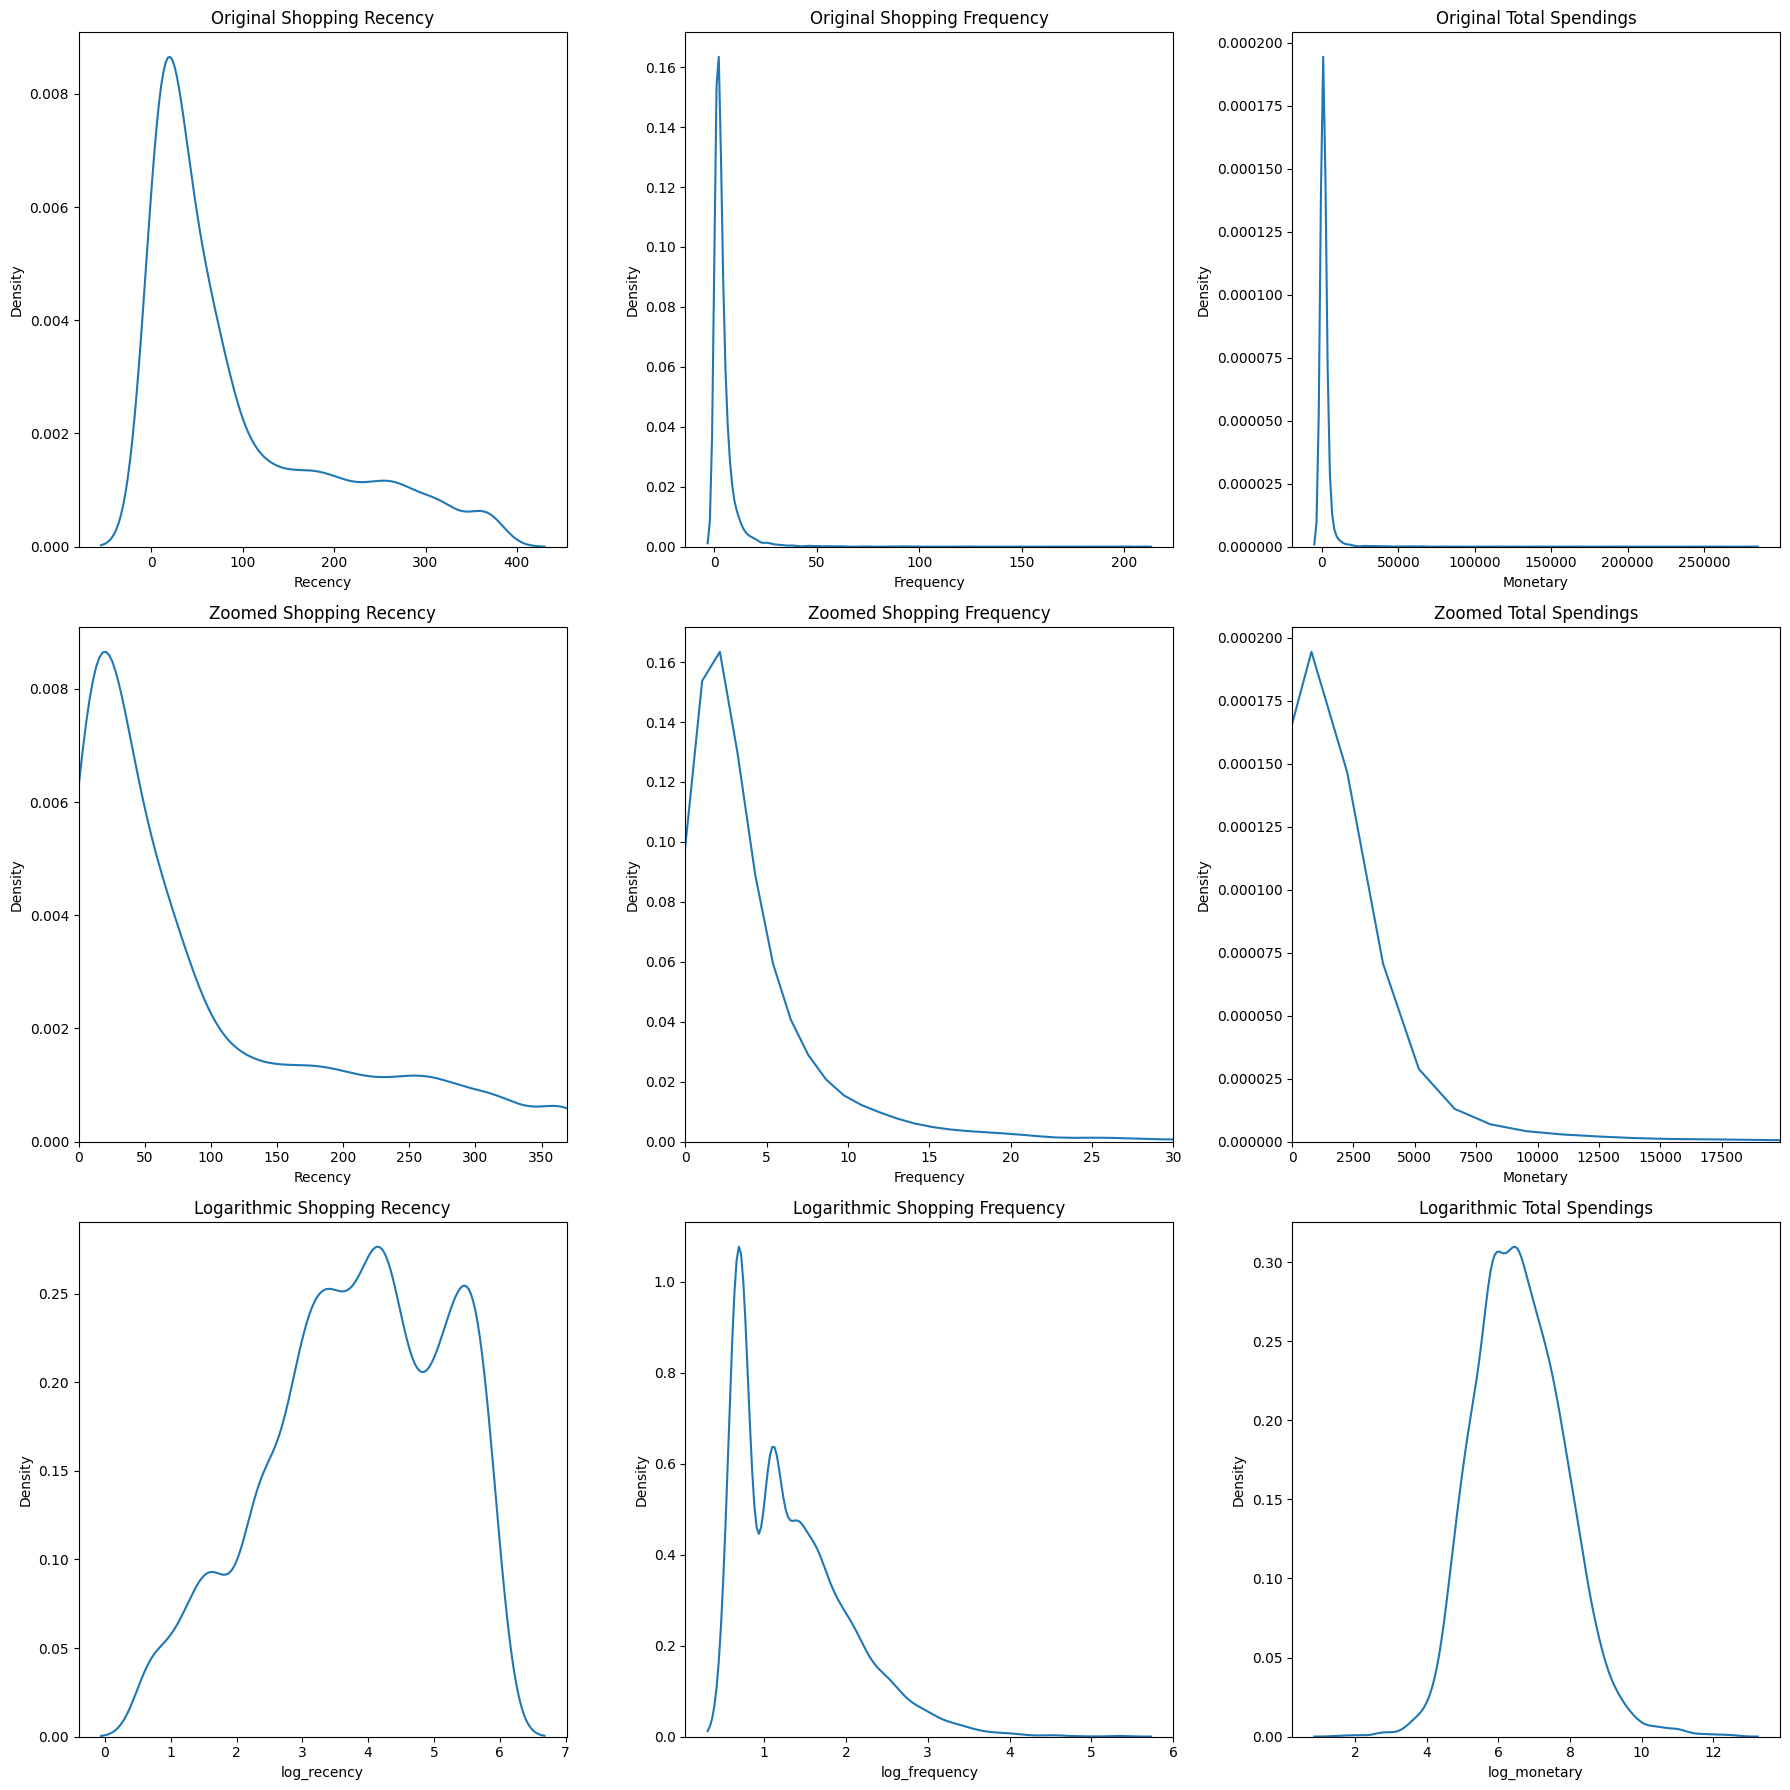

In [41]:
fig,axes = plt.subplots(3,3,figsize=(18,18))

sns.kdeplot(df["Recency"],ax=axes[0,0]).set_title("Original Shopping Recency")
sns.kdeplot(df["Frequency"],ax=axes[0,1]).set_title("Original Shopping Frequency")
sns.kdeplot(df["Monetary"],ax=axes[0,2]).set_title("Original Total Spendings")

sns.kdeplot(df["Recency"],ax=axes[1,0]).set_title("Zoomed Shopping Recency")
sns.kdeplot(df["Frequency"],ax=axes[1,1]).set_title("Zoomed Shopping Frequency")
sns.kdeplot(df["Monetary"],ax=axes[1,2]).set_title("Zoomed Total Spendings")

sns.kdeplot(df["log_recency"],ax=axes[2,0]).set_title("Logarithmic Shopping Recency")
sns.kdeplot(df["log_frequency"],ax=axes[2,1]).set_title("Logarithmic Shopping Frequency")
sns.kdeplot(df["log_monetary"],ax=axes[2,2]).set_title("Logarithmic Total Spendings")

axes[1,0].set_xlim(0,df["Recency"].quantile(0.99))
axes[1,1].set_xlim(0,df["Frequency"].quantile(0.99))
axes[1,2].set_xlim(0,df["Monetary"].quantile(0.99))



plt.tight_layout()
plt.show()

The plots show how the data as like most real data is highly skewed.

### Box and Whiskers plot and barcharts for clearer understanding on how each segment is distributed based on RFM separately

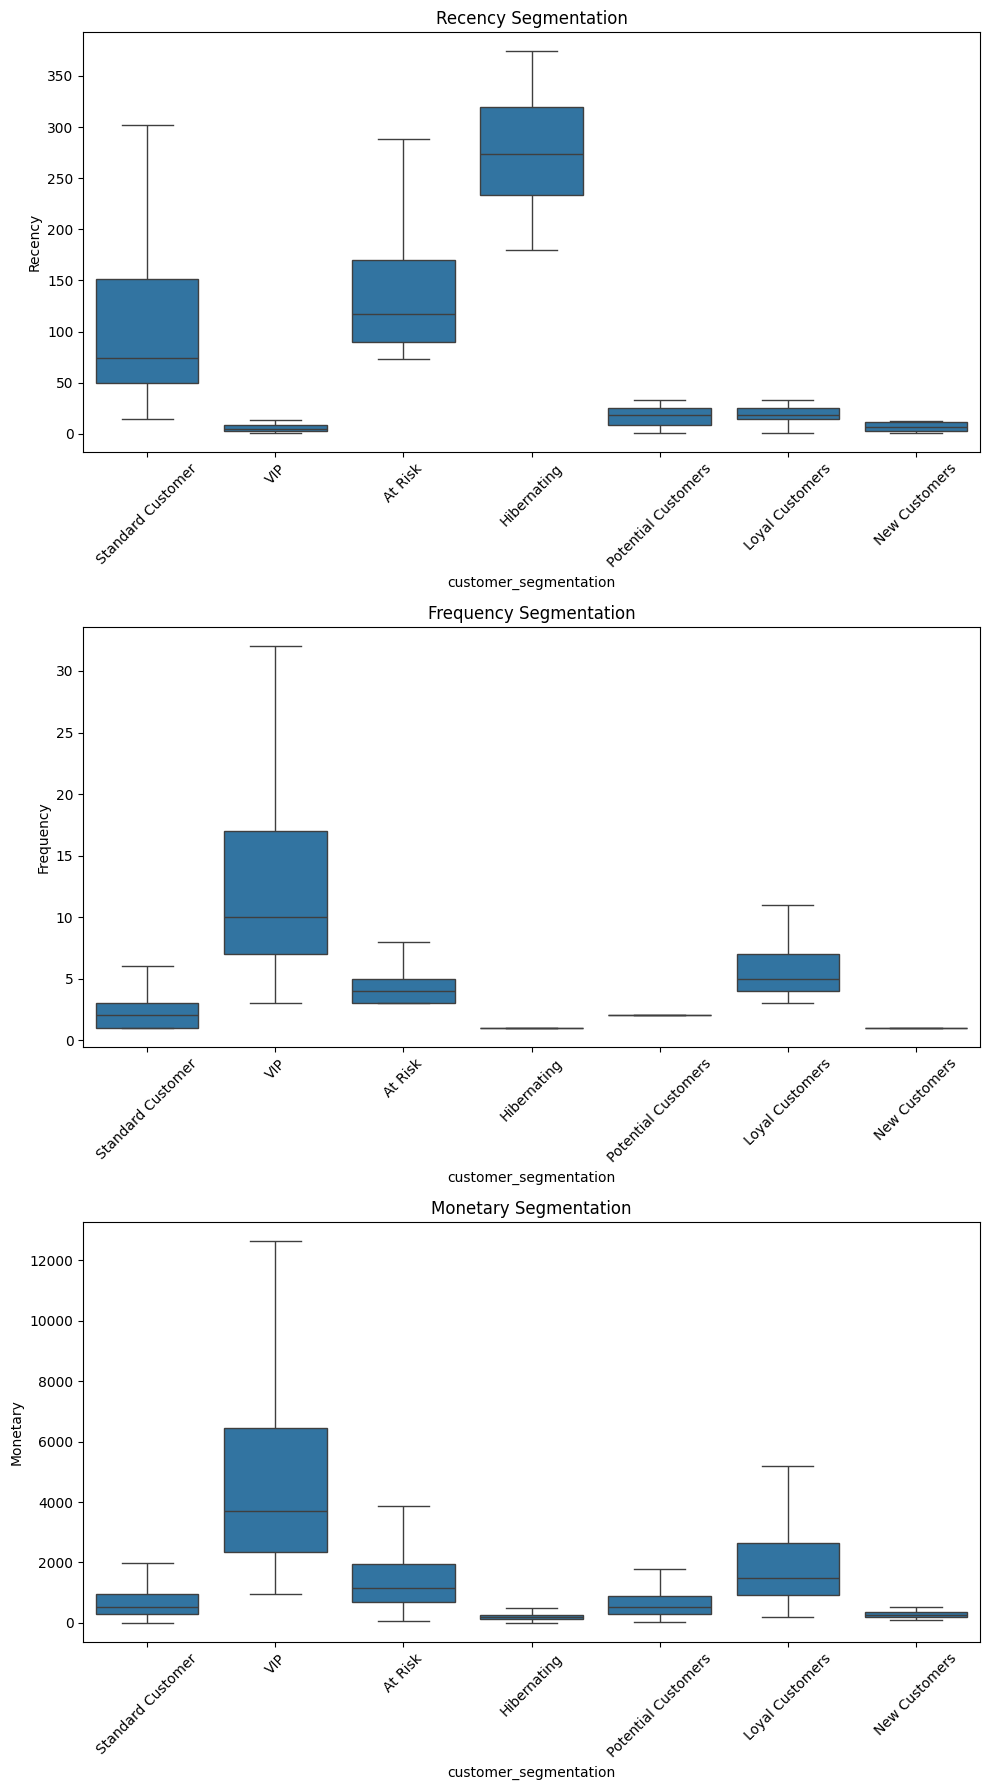

In [120]:
fig,axes = plt.subplots(3,1,figsize=(10,18))

sns.boxplot(data=df,x="customer_segmentation",y="Recency",ax=axes[0],showfliers=False).set_title("Recency Segmentation")
sns.boxplot(data=df,x="customer_segmentation",y="Frequency",ax=axes[1],showfliers=False).set_title("Frequency Segmentation")
sns.boxplot(data=df,x="customer_segmentation",y="Monetary",ax=axes[2],showfliers=False).set_title("Monetary Segmentation")

for ax in axes.flat:
    ax.tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()

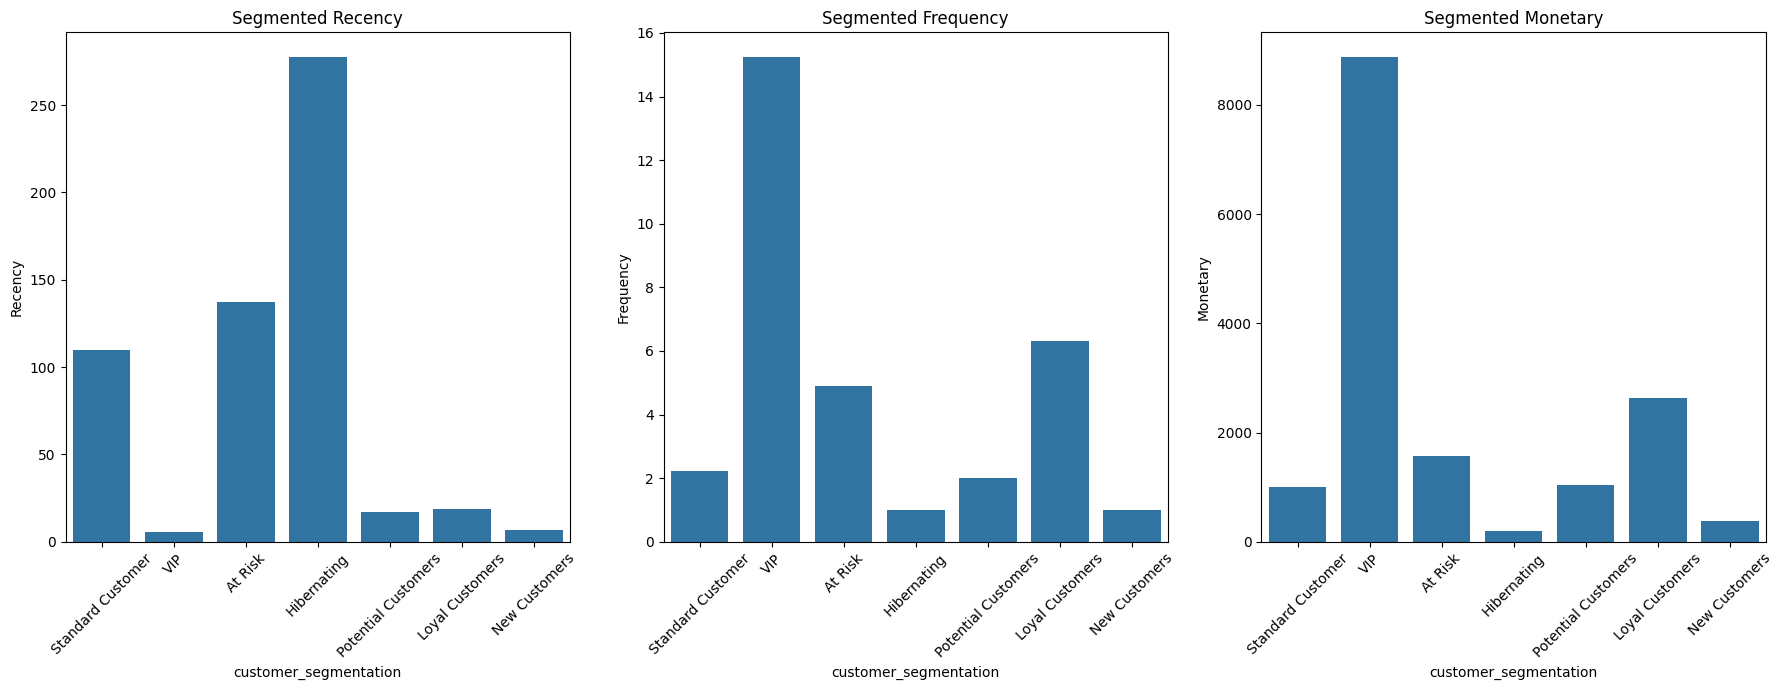

In [112]:
fig,axes = plt.subplots(1,3,figsize=(18,7))
sns.barplot(data=df,y="Recency",x="customer_segmentation",ax=axes[0],errorbar=None).set_title("Segmented Recency")
sns.barplot(data=df,y="Frequency",x="customer_segmentation",ax=axes[1],errorbar=None).set_title("Segmented Frequency")
sns.barplot(data=df,y="Monetary",x="customer_segmentation",ax=axes[2],errorbar=None).set_title("Segmented Monetary")

for ax in axes.flat:
    ax.tick_params(axis="x",rotation=45)

plt.tight_layout()

plt.show()

The box plots and the barcharts confirm that the manual segmentation was applied correctly and Recency, Frequency and Monetary clearly separates each segment.

### Count plot to find the major and minor segments

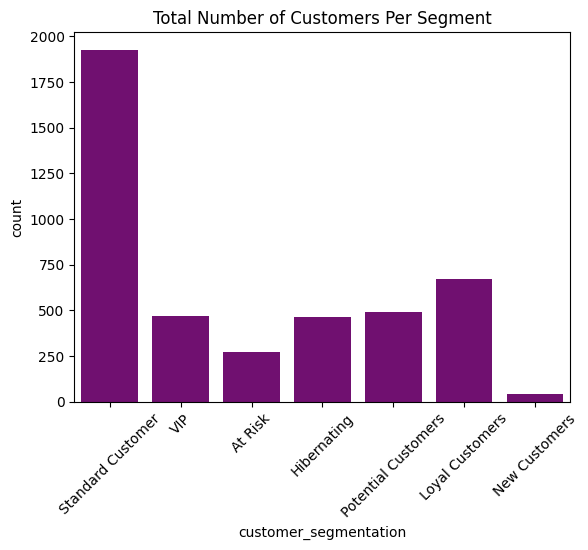

In [118]:
sns.countplot(data=df,x="customer_segmentation",color="Purple")
plt.title("Total Number of Customers Per Segment")
plt.xticks(rotation=45)
plt.show()

The count plot suggest that even though the company has a large number of stable customers, the hibernating customers are alarming as well. On the other hand, number of potential customers are promising as well. This suggests that the compnay should focus on targetted marketing to turn the potential customers to stable, loyal customers while stopping the at risk customers from turning into hibernating ones. 

### The Scatter Plots visualize the paired affect of RFM on each segment

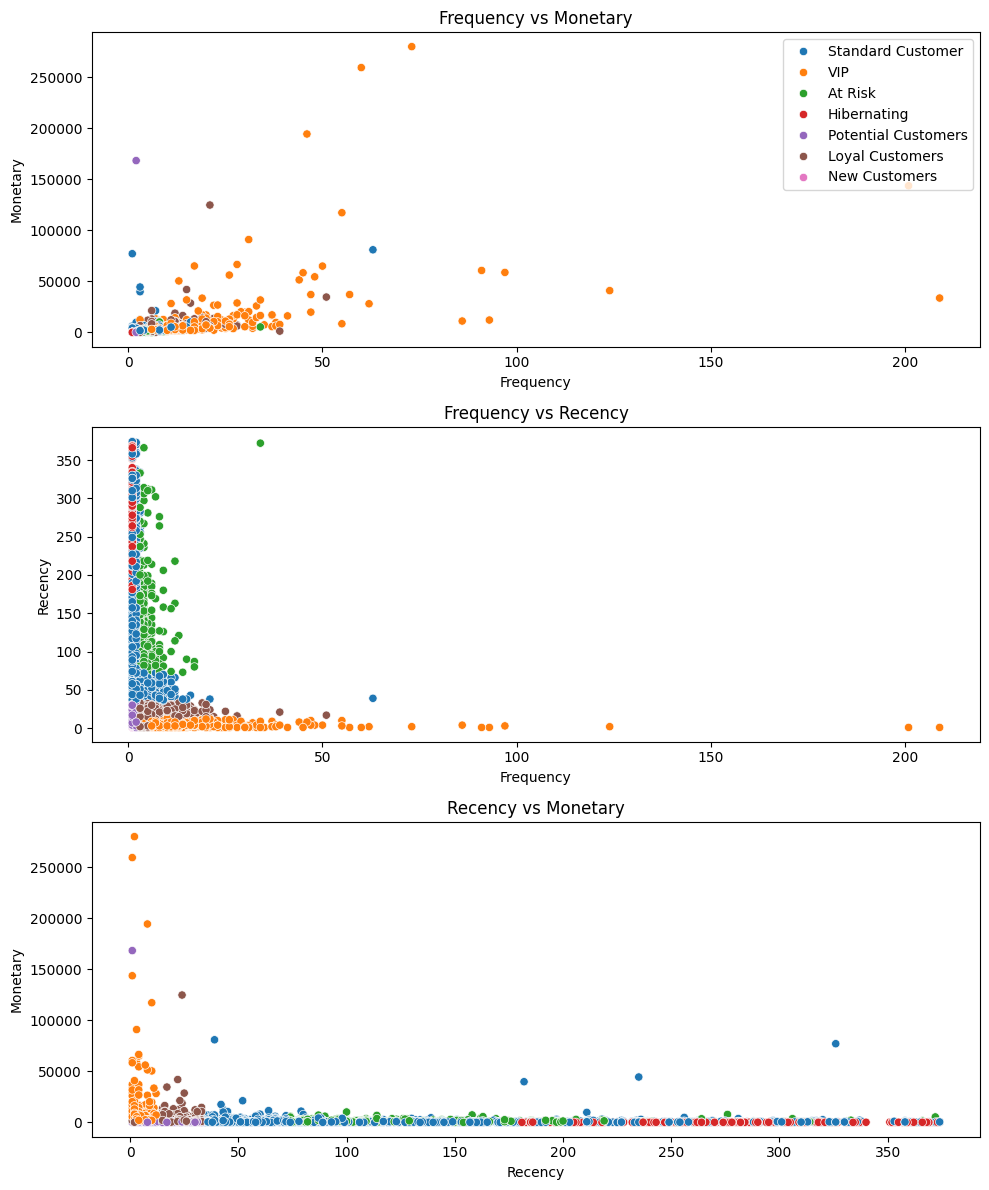

In [122]:
fig,axes = plt.subplots(3,1,figsize=(10,12))
sns.scatterplot(data=df,x="Frequency",y="Monetary",hue="customer_segmentation",ax=axes[0]).set_title("Frequency vs Monetary")
sns.scatterplot(data=df,x="Frequency",y="Recency",hue="customer_segmentation",ax=axes[1],legend=False).set_title("Frequency vs Recency")
sns.scatterplot(data=df,x="Recency",y="Monetary",hue="customer_segmentation",ax=axes[2],legend=False).set_title("Recency vs Monetary")

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()